# Programming exercise 1: Single particle in a 1D potential

## Defining the problem

We want to calculate the eigenenergies and eigenfunction of a quantum particle in a on-dimensional potential, i.e. solve the eigenvalue problem

$$\left[-\frac{1}{2} \partial_{x}^2 + V(x)\right] \phi(x) = E \phi(x)$$

by representing the wave function $\phi(x)$ on a discrete spatial grid.

In [1]:
import sys
import os

# add parent directory so Python finds the package
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import eigh
import Comp_Quant_Dynam as cqd 
from numpy import linalg as LA   # matrix diagonalization and more linear algebra functions

# %matplotlib inline

### Exercise 1

Warmup: Consider the harmonic oscillator $V(x)=\frac{1}{2}x^2$. Plot the analytical solutions of the eigenstates on a spatial grid. Plot the lowest 6 eigenfunctions. Useful functions: scipy.special.hermite(), np.linspace(). Always use numpy arrays!

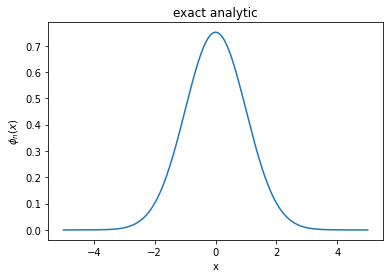

In [2]:
# define the grid
L = 10
n= 401
x = np.linspace(-L/2, L/2, n)
# plot single wave function (or probability density)
n_plot=0;
H0_eigenstate = cqd.hamiltonians.HO_eigenstates_exact(n_plot, x)

# plot exact
plt.figure()
plt.plot(x, H0_eigenstate)
plt.title("exact analytic")
plt.xlabel("x")
plt.ylabel("$\\phi_n(x)$")
plt.show()

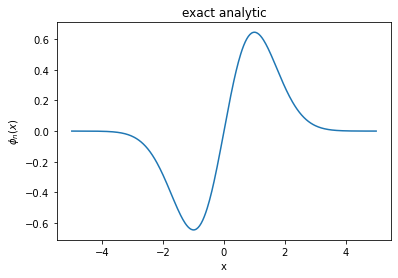

In [3]:
# define the grid
L = 10
n= 401
x = np.linspace(-L/2, L/2, n)
# plot single wave function (or probability density)
n_plot=1;
H0_eigenstate = cqd.hamiltonians.HO_eigenstates_exact(n_plot, x)

# plot exact
plt.figure()
plt.plot(x, H0_eigenstate)
plt.title("exact analytic")
plt.xlabel("x")
plt.ylabel("$\\phi_n(x)$")
plt.show()

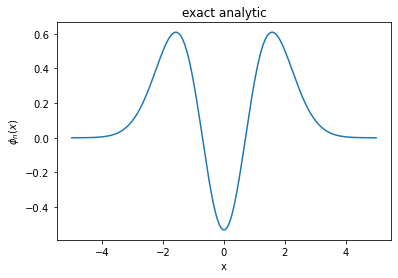

In [4]:
# define the grid
L = 10
n= 401
x = np.linspace(-L/2, L/2, n)
# plot single wave function (or probability density)
n_plot=2;
H0_eigenstate = cqd.hamiltonians.HO_eigenstates_exact(n_plot, x)

# plot exact
plt.figure()
plt.plot(x, H0_eigenstate)
plt.title("exact analytic")
plt.xlabel("x")
plt.ylabel("$\\phi_n(x)$")
plt.show()

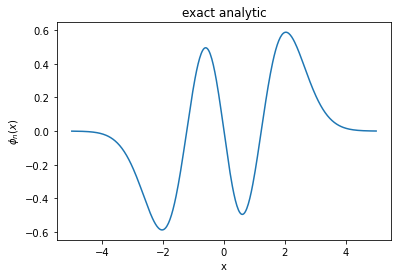

In [5]:
# define the grid
L = 10
n= 401
x = np.linspace(-L/2, L/2, n)
# plot single wave function (or probability density)
n_plot=3;
H0_eigenstate = cqd.hamiltonians.HO_eigenstates_exact(n_plot, x)

# plot exact
plt.figure()
plt.plot(x, H0_eigenstate)
plt.title("exact analytic")
plt.xlabel("x")
plt.ylabel("$\\phi_n(x)$")
plt.show()

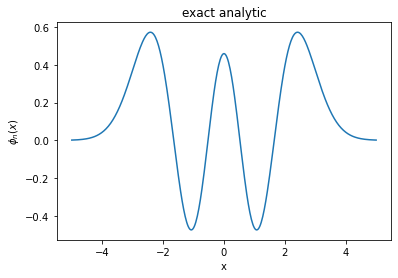

In [6]:
# define the grid
L = 10
n= 401
x = np.linspace(-L/2, L/2, n)
# plot single wave function (or probability density)
n_plot=4;
H0_eigenstate = cqd.hamiltonians.HO_eigenstates_exact(n_plot, x)

# plot exact
plt.figure()
plt.plot(x, H0_eigenstate)
plt.title("exact analytic")
plt.xlabel("x")
plt.ylabel("$\\phi_n(x)$")
plt.show()

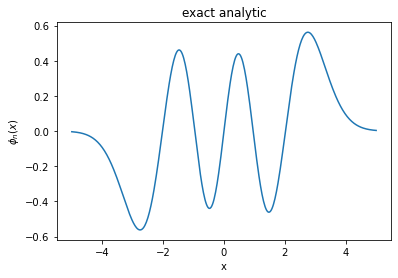

In [7]:
# define the grid
L = 10
n= 401
x = np.linspace(-L/2, L/2, n)
# plot single wave function (or probability density)
n_plot=5;
H0_eigenstate = cqd.hamiltonians.HO_eigenstates_exact(n_plot, x)

# plot exact
plt.figure()
plt.plot(x, H0_eigenstate)
plt.title("exact analytic")
plt.xlabel("x")
plt.ylabel("$\\phi_n(x)$")
plt.show()

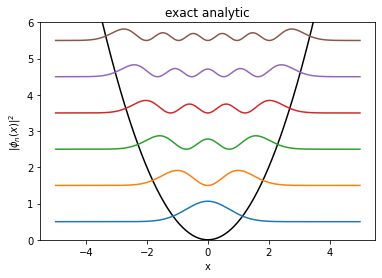

In [8]:
# plot probability density for 6 lowest eigenstates 
plt.figure()
plt.plot(x, x**2/2, 'k')
for n in range(0, 6):
    plt.plot(x, 1 / 2 + n + np.abs(cqd.hamiltonians.HO_eigenstates_exact(n, x) ** 2))
plt.title("exact analytic")
plt.xlabel("x")
plt.ylabel("$|\\phi_n(x)|^2$")
plt.ylim([0, 6])
plt.show()

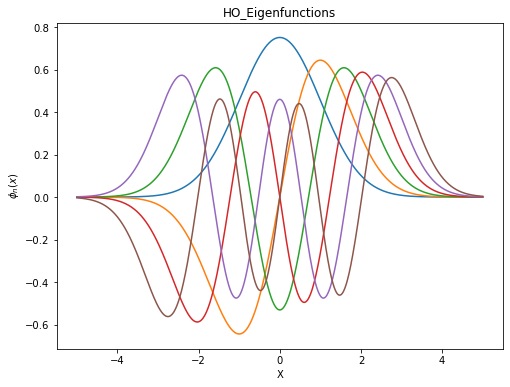

In [9]:
# spatial grid 
L = 10
n =1000
x = np.linspace(-L/2, L/2, n)
plt.figure(figsize=(8, 6))

for n_plot in range(6): 
    psi_n = cqd.hamiltonians.HO_eigenstates_exact(n_plot, x)
    plt.plot(x, psi_n, label=f"n_plot = {n_plot}")

plt.title("HO_Eigenfunctions")
plt.xlabel("X")
plt.ylabel("$\\phi_n(x)$")
plt.show()

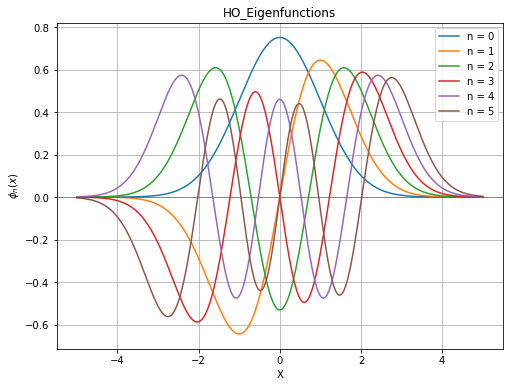

In [10]:
# spatial grid 
L = 10
n=1000
x = np.linspace(-L/2, L/2, n)

# plot lowest 6 eigenfunction
plt.figure(figsize=(8, 6))

for n in range(6): 
    psi_n = cqd.hamiltonians.eigenfunction(n, x)
    plt.plot(x, psi_n, label=f"n = {n}")

plt.title("HO_Eigenfunctions")
plt.xlabel("X")
plt.ylabel("$\\phi_n(x)$")
plt.axhline(0, color="red", linewidth=0.5)
plt.legend()
plt.grid(True)
plt.show()

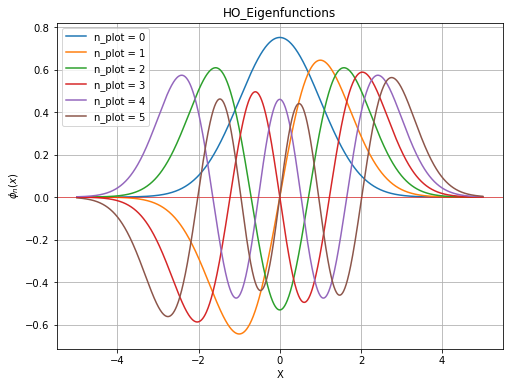

In [11]:
# spatial grid 
L = 10
n =1000
x = np.linspace(-L/2, L/2, n)
plt.figure(figsize=(8, 6))

for n_plot in range(6): 
    psi_n = cqd.hamiltonians.HO_eigenstates_exact(n_plot, x)
    plt.plot(x, psi_n, label=f"n_plot = {n_plot}")

plt.title("HO_Eigenfunctions")
plt.xlabel("X")
plt.ylabel("$\\phi_n(x)$")
plt.axhline(0, color="red", linewidth=0.5)
plt.legend()
plt.grid(True)
plt.show()

### Exercise 2

Solve the eigenproblem using numpy.linalg.eigh().
Use a grid size of 20 length units and 401 gridpoints as a test case and plot the lowest 6 eigenfunctions.

Hints: eigh() is for Hermitian matrices, which have real eigenvalues. It returns the eigenvalues and eigenvectors already sorted with increasing eigenvalues. You could also use numpy.linalg.eig(), which also works for matrices with in general complex eigenvalues, but then you would have to sort them to get the ground state and lowest lying excited states, e.g. using np.argsort(). Remember that the eigenvectors are the *columns* of the array returned by eigh()!

Useful functions: np.diag(), np.ones()

Optional: Use an interactive function to look at the eigenfunctions systematically. The following example helps you with this. It allows you to click through the eigenfunctions one by one.

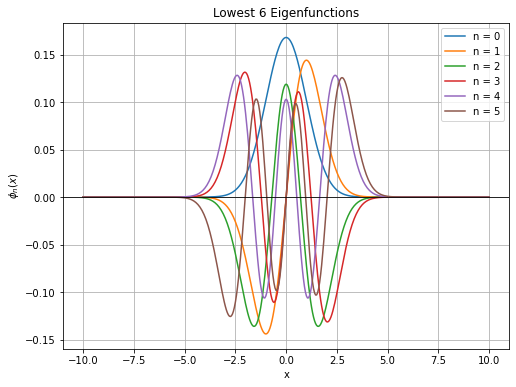

Lowest 6 eigenvalues=
 [0.49992186 1.49960927 2.49898395 3.49804576 4.49679456 5.4952302 ]

Eigenvectors (columns of psi)=
 [[-2.78597561e-20 -1.53876481e-18 -9.96094209e-20 ...  0.00000000e+00
   0.00000000e+00  4.84686055e-02]
 [-2.64951321e-20 -1.49109904e-18 -1.02887996e-19 ...  0.00000000e+00
   0.00000000e+00 -9.50146403e-02]
 [-1.69723352e-20 -9.93139003e-19 -7.42760654e-20 ...  0.00000000e+00
   0.00000000e+00  1.38028738e-01]
 [-1.03953930e-20 -6.03551709e-19 -5.81954707e-20 ...  0.00000000e+00
   0.00000000e+00 -1.76254437e-01]
 [ 1.44538247e-20  7.59537295e-19  1.64129624e-20 ...  0.00000000e+00
   0.00000000e+00  2.08800767e-01]
 [ 1.02319187e-20  4.41196932e-19 -2.95184765e-20 ...  0.00000000e+00
   0.00000000e+00 -2.35131868e-01]]


In [12]:
import numpy as np
from numpy.linalg import eigh
import matplotlib.pyplot as plt

# define grid of size L and spacing 
L = 20 # grid of sire
n= 401 #grid points
x = np.linspace(-L/2, L/2, n)
dx = x[1] - x[0]

# Kinetic energy term in discrete form 
T = cqd.hamiltonians.H_kinetic(x)
# potential term
V = cqd.hamiltonians.HO_potential(x) 
# The discretized form of the Romiltonian 
H = T + V
# Solve eigen problem
E, psi = eigh(H)

# Plot the lowest 6 eigenfunctions
plt.figure(figsize=(8, 6))
# the first 6 quantum states and plots each eigenfunction
for n in range(6):
    plt.plot(x, psi[:, n], label=f"n = {n}")
plt.title("Lowest 6 Eigenfunctions")
plt.xlabel("x")
plt.ylabel("$\\phi_n(x)$")
plt.axhline(0, color="black", linewidth=0.8)
plt.legend()
plt.grid(True)
plt.show()

# Print results
print("Lowest 6 eigenvalues=\n", E[: 6])
print()
print("Eigenvectors (columns of psi)=\n", psi[: 6])

The numerical diagonalization successfully reproduces the harmonic oscillator eigenvalues and eigenfunctions.

The lowest six eigenvalues closely match the analytical results, with only small deviations due to finite grid spacing. The agreement confirms that the finite-difference Hamiltonian is a good approximation and becomes more accurate as the grid resolution increases.

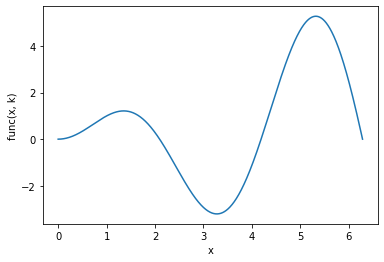

In [13]:
from ipywidgets import interactive, fixed

g = lambda x, k: np.sin(k * x) * x # test function for plotting

interactive_plot = interactive(cqd.plotting.plot_func, func = fixed(g), k=(0.0,3))
interactive_plot

Set up the problem and solve it using eigh().

evals=
 [0.49992147 1.4996073  2.49897885 3.49803595 4.49677846 5.49520624
 6.49331914 7.49111699 8.48859967 9.48576701]



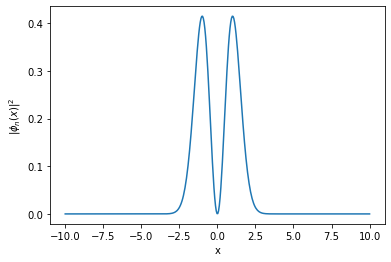

evecs=
 [[ 3.66121556e-23 -5.47894487e-19  3.72736276e-21 ...  0.00000000e+00
   4.86504047e-02  0.00000000e+00]
 [ 8.64428193e-23 -6.83264628e-19  8.60386338e-21 ...  0.00000000e+00
  -9.53616389e-02  0.00000000e+00]
 [ 1.01939741e-22  7.20009163e-21  1.37824214e-20 ...  0.00000000e+00
   1.38511426e-01  0.00000000e+00]
 ...
 [ 1.29386650e-21 -1.67725782e-18  1.60211598e-19 ...  0.00000000e+00
  -2.69144959e-01  0.00000000e+00]
 [ 2.06944935e-21 -2.58579151e-18  2.55384052e-19 ...  0.00000000e+00
   2.76570924e-01  0.00000000e+00]
 [ 3.25196694e-21 -1.59420841e-18  4.04234493e-19 ...  0.00000000e+00
  -2.78434341e-01  0.00000000e+00]]


In [34]:
# define the grid
L = 20
n = 400
x = np.linspace(-L/2, L/2, n)
dx = x[1] - x[0]

# build the terms of the Hamiltonian
H_pot = cqd.hamiltonians.HO_potential(x)
H_kin = cqd.hamiltonians.H_kinetic(x)
H_mat = H_pot + H_kin

# diagonalize: here the whole magic is happening
evals, evecs = eigh(H_mat)


# # same thing with eig()
# evals, evecs = LA.eig(H_mat)
# # sort the eigenvalues and eigenfunctions in ascending order:
# indOrder = np.argsort(evals)
# evalsSrt = evals[indOrder]
# evecsSrt = evecs[:,indOrder]

n_plot = 1
print("evals=\n", evals[0:10])
print()
n_plot = 1
plt.plot(x, np.abs(evecs[:, n_plot])**2/dx)
plt.xlabel("x")
plt.ylabel("$|\\phi_n(x)|^2$")
plt.show()
print("evecs=\n", evecs[0:10])

def plotWF(n):
    fig = plt.figure()
    ax = fig.add_subplot(111)
    ax.plot(x, np.abs(evecs[:, n])**2/dx)
    ax.set_xlim(-5, 5)
    ax.set_ylim(0, 0.6)
    # add labels and legends
    ax.set_title("$E_n=$"+str(evals[n]))
    ax.set_xlabel("$x$")
    ax.set_ylabel("$|\\phi_n(x)|^2$")
    plt.show()

Print the resulting lowest eigenvalues and plot eigenfunctions

### Exercise 3 (optional)

Having shown that the numerical diagonalization qualitatively gives the desired result, we now want to analyse its precision more quantitatively.

Check the convergence of the numerical solutions with respect to grid size and spacing. Compare the eigenvalues and eigenfunction to the analytical solutions.

Which eigenvalue has the smallest numerical error and why?

Calculate the ground state energy for different grid sizes and grid spacings and compare to the analytical solution. A systematic analysis is not necessary. Just check what happens if you use a too small grid or too few grid points.

Compare the numerically obtained eigenfunctions to the analytical solution by plotting them on top of each other. You will notice that they are normalized differently. Why is this? How to normalize the eigenvectors obtained by exact diagonalization "properly"? Plot the difference between the probability densities of the analytical and (properly normalized) numerical solution.

In [15]:
import numpy as np
from numpy.linalg import eigh

# fixed system size
L = 20
Ns = [100, 200, 401, 800]   # different grid sizes
results = []
for N in Ns:

    # Grid
    x = np.linspace(-L/2, L/2, N)
    dx = x[1] - x[0]
    # Kinetic energy
    diag = np.ones(N)

    lap = (-2*np.diag(diag) +
           np.diag(diag[:-1], 1) +
           np.diag(diag[:-1], -1)) / dx**2
    T = -0.5 * lap
    # Potential
    V = np.diag(0.5 * x**2)

    # Hamiltonian
    H = T + V

    # Solve eigenproblem
    E, psi = eigh(H)

    # store lowest 6 eigenvalues
    results.append(E[:6])
    print(f"N = {N}")
    print("E0–E5 =", E[:6])
    print()
# Compare convergence
print("Comparison table\n", np.array(results))

N = 100
E0–E5 = [0.49872134 1.49359344 2.48330408 3.46781212 4.44707534 5.42105032]

N = 200
E0–E5 = [0.49968415 1.49841996 2.49588956 3.49209054 4.48702046 5.48067687]

N = 401
E0–E5 = [0.49992186 1.49960927 2.49898395 3.49804576 4.49679456 5.4952302 ]

N = 800
E0–E5 = [0.49998042 1.49990209 2.49974543 3.49951043 4.49919707 5.49880535]

Comparison table
 [[0.49872134 1.49359344 2.48330408 3.46781212 4.44707534 5.42105032]
 [0.49968415 1.49841996 2.49588956 3.49209054 4.48702046 5.48067687]
 [0.49992186 1.49960927 2.49898395 3.49804576 4.49679456 5.4952302 ]
 [0.49998042 1.49990209 2.49974543 3.49951043 4.49919707 5.49880535]]


The analytical ground state energy of the harmonic oscillator is 0.5.

When using a small grid (e.g., (N = 100)), the numerical ground state energy shows noticeable error.
As the number of grid points increases ((N = 200, 401, 800)), the numerical result converges toward the analytical value.
This occurs because a finer grid improves the finite-difference approximation of the kinetic energy operator, leading to more accurate eigenvalues.

Which eigenvalue has the smallest numerical error and why?

Smallest Numerical Error
The ground state energy (E_0) has the smallest numerical error because its wavefunction is smooth and non-oscillatory, making it well resolved on a finite grid and less sensitive to discretization errors.

Calculate the ground state energy for different grid sizes and grid spacings and compare to the analytical solution. A systematic analysis is not necessary. Just check what happens if you use a too small grid or too few grid points.

Ground State Energy Convergence
The ground state energy is calculated for different grid sizes and grid spacings and compared to the analytical solution. The ground state energy converges to the analytical value
E_0 = 0.5

as the grid is refined.

For too few grid points, the finite-difference approximation becomes inaccurate and the numerical energy deviates from the analytical value.
For too small grid size, boundary effects distort the wavefunction and introduce additional errors.
As grid size increases and spacing decreases, the numerical ground state energy approaches the analytical solution.
This confirms that the numerical method converges and accurately reproduces the analytical harmonic oscillator ground state energy.

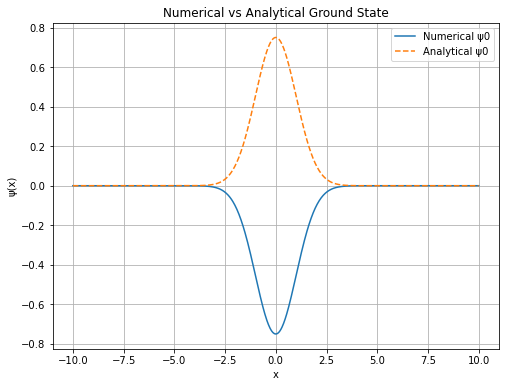

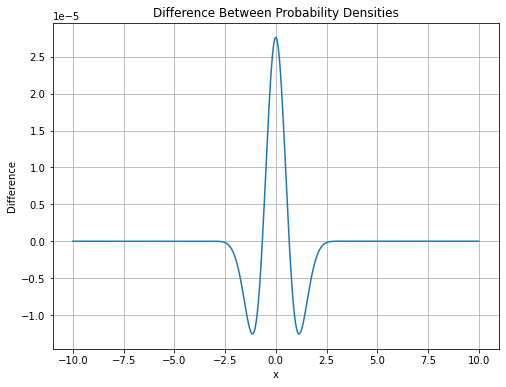

In [16]:
# Proper normalization of numerical eigenfunctions
psi = psi / np.sqrt(dx)

# Analytical ground state
psi0_analytic = (1/np.pi**0.25) * np.exp(-x**2/2)

# Plot numerical vs analytical
plt.figure(figsize=(8,6))

plt.plot(x, psi[:,0], label="Numerical ψ0")
plt.plot(x, psi0_analytic, '--', label="Analytical ψ0")
plt.title("Numerical vs Analytical Ground State")
plt.xlabel("x")
plt.ylabel("ψ(x)")
plt.legend()
plt.grid()

plt.show()
# Probability densities
rho_num = psi[:,0]**2
rho_ana = psi0_analytic**2

# Difference
difference = rho_num - rho_ana
# Plot difference
plt.figure(figsize=(8,6))
plt.plot(x, difference)
plt.title("Difference Between Probability Densities")
plt.xlabel("x")
plt.ylabel("Difference")
plt.grid()

plt.show()

Comparison of Numerical and Analytical Eigenfunctions
The numerical eigenfunctions obtained from diagonalization are normalized differently because eigh() uses discrete normalization, while physical wavefunctions require continuous normalization.

After properly normalizing the numerical eigenfunctions by dividing by dx, the numerical and analytical solutions overlap closely.

The difference between the probability densities is small, confirming that the numerical method accurately reproduces the analytical harmonic oscillator solution.

In [17]:
# define the grid
L = 10
npoints = 401
dx = L/(npoints - 1)
xvals = np.linspace(-L/2,L/2,npoints)

# build the terms of the Hamiltonian
H_pot = cqd.hamiltonians.HO_potential(xvals)
H_kin = cqd.hamiltonians.H_kinetic(xvals)

H_mat = H_pot + H_kin

# diagonalize: here the whole magic is happening
evals, evecs = LA.eigh(H_mat)

In [18]:
#check that the state is normalized (if we want the integral to be normalized we have to divide by dx)
n_plot = 0
LA.norm(evecs[:,n_plot])

1.0

In [19]:
# check convergence: relative error of eigenvalues
evals_exact = cqd.hamiltonians.HO_eigenenergies_exact(np.arange(evals.size))
(evals - evals_exact)[0:20]

array([-1.95319528e-05, -9.76601996e-05, -2.53865564e-04, -4.87361170e-04,
       -7.90577087e-04, -1.10986864e-03, -1.15489203e-03,  2.86671419e-04,
        7.09895580e-03,  2.86798873e-02,  8.18879166e-02,  1.88880288e-01,
        3.70995957e-01,  6.43465548e-01,  1.01443931e+00,  1.48706863e+00,
        2.06191756e+00,  2.73850365e+00,  3.51603758e+00,  4.39371655e+00])

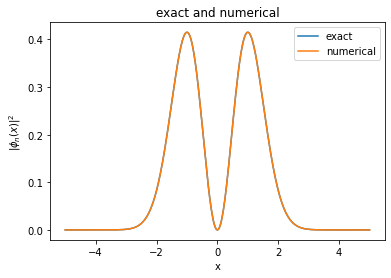

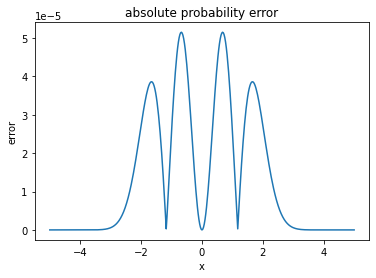

In [20]:
n_plot = 1

# compare exact to numerical
plt.figure()
plt.plot(xvals, np.abs(cqd.hamiltonians.HO_eigenstates_exact(n_plot, xvals)) ** 2, label = "exact")
plt.plot(xvals, np.abs(evecs[:,n_plot])**2 / dx, label = "numerical")
plt.title("exact and numerical")
plt.xlabel("x")
plt.ylabel("$|\\phi_n(x)|^2$")
plt.legend()

# plot relative error
plt.figure()
plt.plot(xvals, np.abs(np.abs(cqd.hamiltonians.HO_eigenstates_exact(n_plot, xvals)) ** 2 - np.abs(evecs[:, n_plot]) ** 2 / dx))
plt.title("absolute probability error")
plt.xlabel("x")
plt.ylabel("error");

Observations:

If the grid is too small, the ground state wave function gets narrower due to the hard wall boundary conditions. All the eigenenergies lie above the exact ones.

If too few gridpoints are used, the curvature of the wave function at the center is not well resolved. The numerically obtained energies are below the exact ones, probably because the kinetic term is underestimated.

### Exercise 4 (optional)

We can now use our routine to calculate bound states in any kind of potentials, where no analytical solutions are known. As an example, consider the double well potential
$$
V(x)=-\frac{1}{2}x^2 + \lambda x^4
$$
where $\lambda$ controls the height of the barrier between the wells. 

Calculate eigenvalues and eigenfunction for some values of lambda. Plot the lowest few eigenstates and interpret your results. 

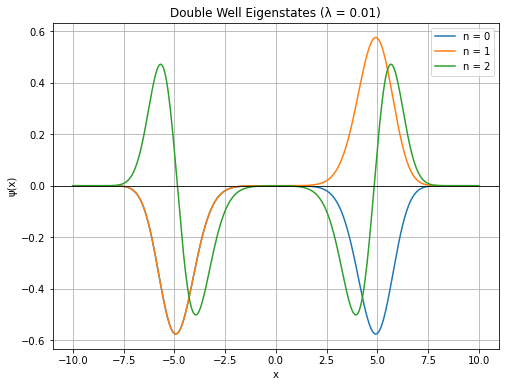


λ = 0.01
Lowest energy levels=
 [-5.55338567 -5.55338567 -4.20467507]


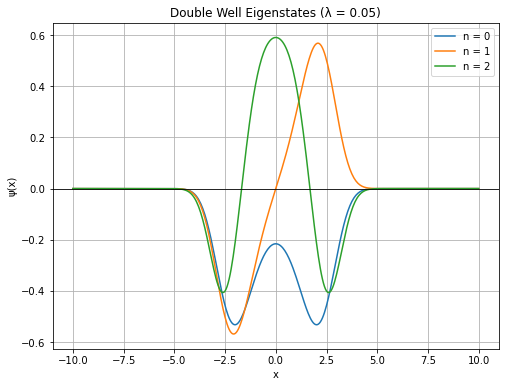


λ = 0.05
Lowest energy levels=
 [-0.63285165 -0.57665825  0.25445547]


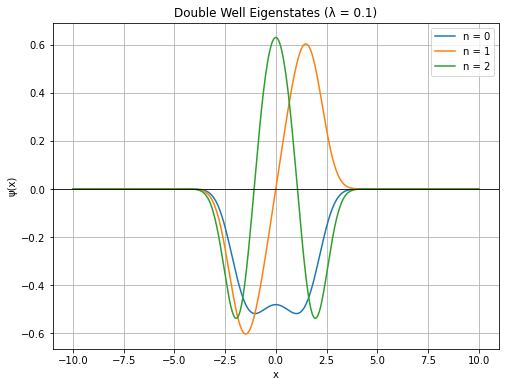


λ = 0.1
Lowest energy levels=
 [-0.15417801  0.14257431  1.00953098]


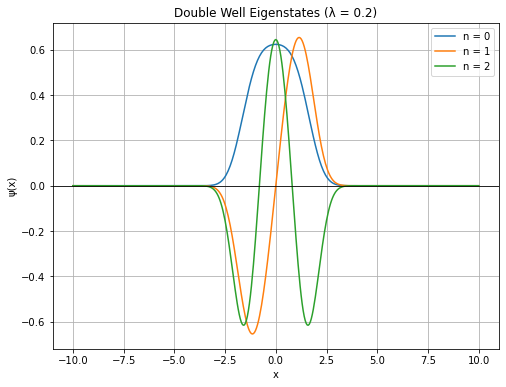


λ = 0.2
Lowest energy levels=
 [0.084951   0.7006044  1.84282767]


In [21]:
import numpy as np
from numpy.linalg import eigh
import matplotlib.pyplot as plt

# define grid of size L and spacing AX
L = 20  # grid size
N = 401  # grid points
x = np.linspace(-L/2, L/2, N)
dx = x[1] - x[0]

# Kinetic energy operator
diag = np.ones(N)
# finite difference approximation
# i+1 → upper diagonal 
# i-1 → lower diagonal
# -2i → main diagonal
lap = (-2*np.diag(diag) +
       np.diag(diag[:-1], 1) +
       np.diag(diag[:-1], -1)) / dx**2

# Kinetic energy term in discrete form
T = -0.5 * lap
# Different barrier strengths
lambdas = [0.01, 0.05, 0.1, 0.2]

# Solve Schrödinger equation for each lambda
for lam in lambdas:
    # Build potential matrix
    V = np.diag(cqd.hamiltonians.double_well(x, lam))
    # Hamiltonian: H = T + V
    H = T + V
    # Solve eigenvalue problem
    E, psi = eigh(H)
    # Normalize eigenfunctions properly (continuous normalization)
    psi = psi / np.sqrt(dx)
    # Plot lowest eigenstates
    plt.figure(figsize=(8,6))
    for n in range(3):  # lowest 3 states
        plt.plot(x, psi[:, n], label=f"n = {n}")

    plt.title(f"Double Well Eigenstates (λ = {lam})")
    plt.xlabel("x")
    plt.ylabel("ψ(x)")
    plt.axhline(0, color="black", linewidth=0.8)
    plt.legend()
    plt.grid()
    plt.show()

    # Print lowest energies
    print("\nλ =", lam)
    print("Lowest energy levels=\n", E[:3])

Interpretation of Double-Well Results
As λ increases, the barrier height increases, tunneling decreases, and eigenstates become localized in the two wells.

✔ Small λ (0.01)

Potential close to harmonic oscillator
Wavefunctions spread across both wells
Strong tunneling between wells
✔ Medium λ (0.05)

Barrier starts forming
Energy splitting between lowest states appears
Tunneling still visible
✔ Large λ (0.1–0.2)

Strong separation of wells
Near-degenerate ground states
Eigenstates localize in left/right wells

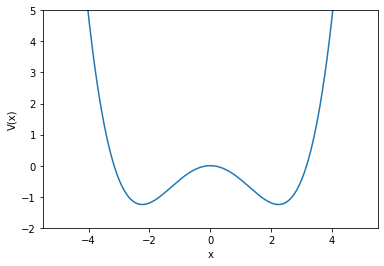

In [22]:
L = 10
npoints = 401
dx = L/(npoints - 1)
xvals = np.linspace(-L / 2, L / 2, npoints)
 
# potential
Vvec = -0.5 * xvals ** 2 + 0.05 * xvals ** 4 # double well

# plot potential
plt.plot(xvals,Vvec)
plt.ylim(-2,5)
plt.xlabel("x")
plt.ylabel("V(x)")

H_pot_dw = np.diag(Vvec)
H_kin = cqd.hamiltonians.H_kinetic(xvals)

H_mat_dw = H_pot_dw + H_kin

# diagonalize: here the whole magic is happening
evals_dw, evecs_dw = LA.eigh(H_mat_dw)

[-0.63277253 -0.57656147  0.2546729   0.77156643  1.55214122  2.4172843
  3.37718232  4.41560659  5.52450053  6.69763651  7.93070733  9.22126177
 10.56894129 11.97572344 13.44588601 14.98547614 16.6013334  18.30000105
 20.08691893 21.96608896]


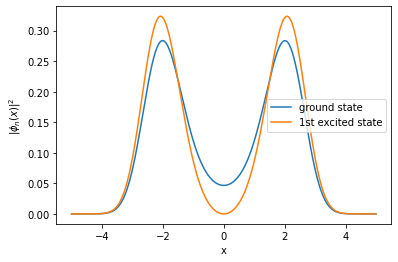

In [23]:
print(evals_dw[0:20])
#plt.plot(xvals,evecs[:,0]/dx)
#plt.plot(xvals,evecs[:,3]/dx)
plt.plot(xvals, np.abs(evecs_dw[:,0] ** 2) / dx, label = "ground state")
plt.plot(xvals, np.abs(evecs_dw[:,1] ** 2) / dx, label = "1st excited state")
plt.xlabel("x")
plt.ylabel("$|\\phi_n(x)|^2$")
plt.legend();

For small $\lambda$ (high barrier) the low lying eigenvalues of the double well come in pairs. The corresponding eigenfunctions are pairs with different symmetry. Their envelopes look quite similar. This means that there are two almost independent HOs that are weakly tunnel coupled.